# Banana Project

In [48]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, mean_squared_error, r2_score, RocCurveDisplay, roc_auc_score


In [2]:
df = pd.read_csv("banana_quality_dataset.csv")
df.set_index('sample_id', inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 1 to 1000
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   variety             1000 non-null   str    
 1   region              1000 non-null   str    
 2   quality_score       1000 non-null   float64
 3   quality_category    1000 non-null   str    
 4   ripeness_index      1000 non-null   float64
 5   ripeness_category   1000 non-null   str    
 6   sugar_content_brix  1000 non-null   float64
 7   firmness_kgf        1000 non-null   float64
 8   length_cm           1000 non-null   float64
 9   weight_g            1000 non-null   float64
 10  harvest_date        1000 non-null   str    
 11  tree_age_years      1000 non-null   float64
 12  altitude_m          1000 non-null   float64
 13  rainfall_mm         1000 non-null   float64
 14  soil_nitrogen_ppm   1000 non-null   float64
dtypes: float64(10), str(5)
memory usage: 117.3 KB


In [3]:
print(df.isna().sum())

variety               0
region                0
quality_score         0
quality_category      0
ripeness_index        0
ripeness_category     0
sugar_content_brix    0
firmness_kgf          0
length_cm             0
weight_g              0
harvest_date          0
tree_age_years        0
altitude_m            0
rainfall_mm           0
soil_nitrogen_ppm     0
dtype: int64


**What we want to do with the data**
We want to predict the quality of the banana. We are given two measures of quality – score and category. First, let's see if these features are directly correlated

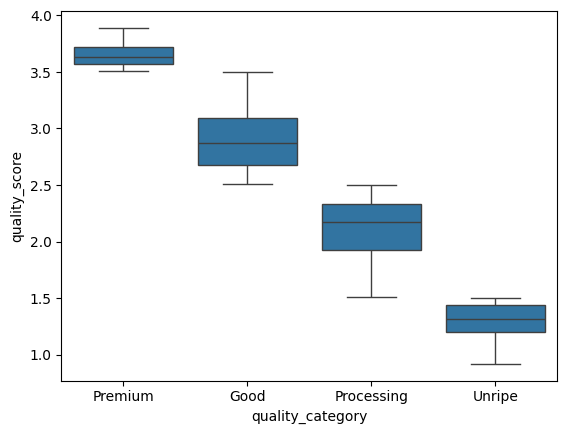

In [4]:
sns.boxplot(x="quality_category", y="quality_score", data=df, order=["Premium", "Good", "Processing", "Unripe"])

plt.show()

In [5]:
#Checking to see where the boundaries fall for the quality score and category (box plot does not show the exact cutoff)
print(df[df['quality_score'] == 1.5]['quality_category'].value_counts())
print(df[df['quality_score'] == 2.5]['quality_category'].value_counts())
print(df[df['quality_score'] == 3.5]['quality_category'].value_counts())


quality_category
Unripe    2
Name: count, dtype: int64
quality_category
Processing    9
Name: count, dtype: int64
quality_category
Good    4
Name: count, dtype: int64


As we can see from this analysis, quality score and category are directly related as such:
- Scores between [Minimum, 1.5] are in the Unripe category
- Scores between (1.5, 2.5] are in the Processing category
- Scores between (2.5, 3.5] are in the Good category
- Scores between (3.5, Maximum] are in the Unripe category

Therefore, we can make either a classification model OR a regression model for this dataset! We decided to try some different models out, so we will do both a decision tree that predicts the class of quality_score and a linear regression model that predicts the value of quality_rating. Because these two target variables are perfectly aligned with eachother via score thresholds, we can directly compare these two types of models and determine which performs better. 

### Pre Processing the X Variables

In [6]:
X = df.drop(columns=['quality_score', 'quality_category'])

In [7]:
NUM = X.select_dtypes(include=np.number).columns.tolist()
X[NUM].describe()

,ripeness_index,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.042170,18.516830,2.706840,19.882100,164.738930,10.879600,723.556700,1972.992800,104.391300
std,1.753211,2.034812,1.289252,5.736318,49.163073,5.215554,427.372855,564.467912,53.607794
min,1.020000,15.000000,0.500000,10.000000,81.050000,2.000000,0.400000,1000.500000,10.000000
25%,2.447500,16.827500,1.590000,14.902500,122.397500,6.300000,353.950000,1498.750000,60.150000
50%,4.110000,18.500000,2.680000,19.890000,163.365000,10.700000,726.000000,1957.400000,104.100000
75%,5.562500,20.312500,3.820000,24.800000,205.775000,15.600000,1071.725000,2431.800000,149.850000
max,7.000000,21.980000,5.000000,29.950000,249.890000,20.000000,1498.400000,2992.000000,199.900000


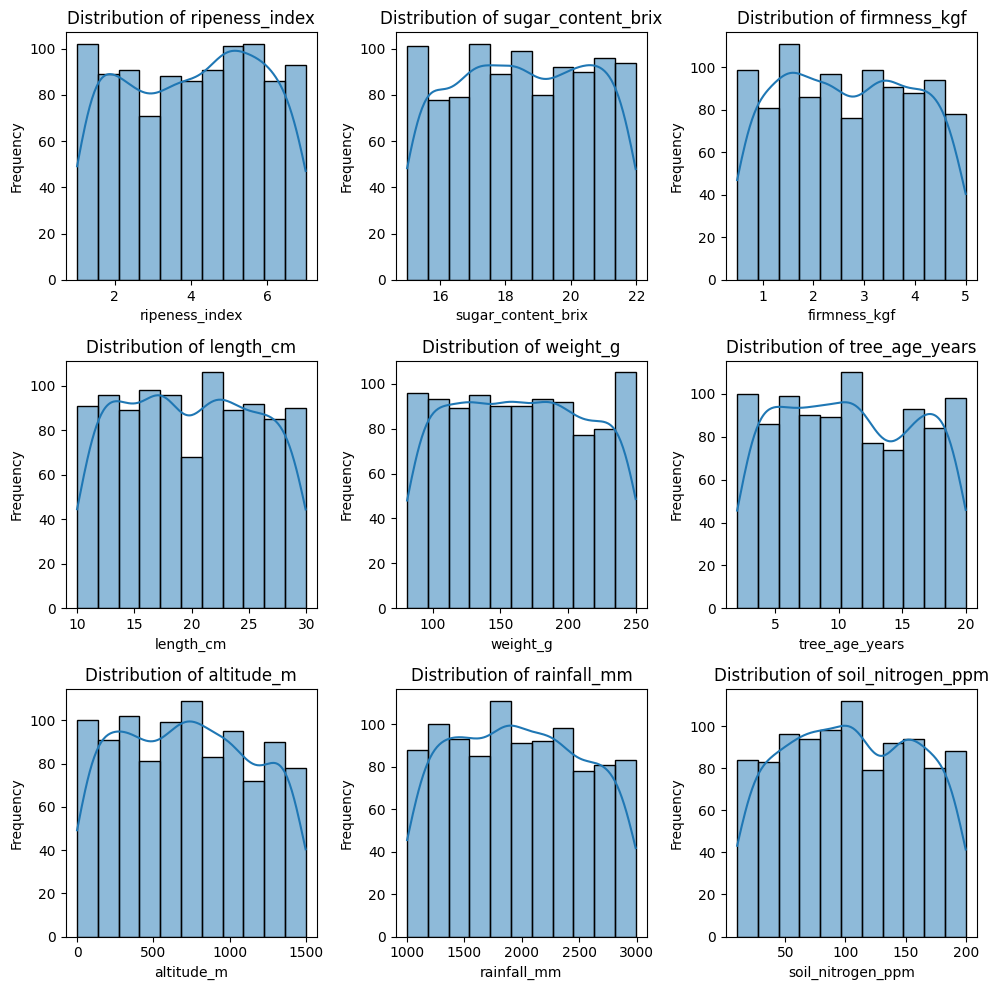

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i,col in enumerate(NUM):
    sns.histplot(X[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

These numerical variables are already normalized

In [9]:
CAT = X.select_dtypes(include='str').columns.tolist()
print(CAT)

['variety', 'region', 'ripeness_category', 'harvest_date']


- The feature "variety" has 8 categories, all of which are evenly distributed. Therefore, we will keep all categories of "variety".
- The feature 'ripeness category' is redundant with ripeness index, so we will remove it. 
- The feature harvest date is not relevant, so we will remove it.


In [10]:
X = X.drop(columns=['ripeness_category', 'harvest_date'])

- The feature "region" has 8 categories, all of which are evenly distibuted. However, we will collapse these features into larger regions to reduce the amount of categories.

In [11]:
X['region'] = X['region'].replace({
    'Ecuador': 'South America',
    'Colombia': 'South America',
    'Brazil': 'South America',
    'Costa Rica': 'Central America',
    'Guatemala': 'Central America',
    'Honduras': 'Central America',
    'Philippines': 'Asia',
    'India': 'Asia'
})

X['region'].value_counts()
    

region
South America      377
Central America    363
Asia               260
Name: count, dtype: int64

In [12]:
#redefining CAT after editing the categorical columns
CAT = X.select_dtypes(include='str').columns.tolist()
X.head()

,variety,region,ripeness_index,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
sample_id,,,,,,,,,,,
1,Manzano,South America,2.11,16.83,3.53,21.44,146.92,13.7,58.2,2440.5,183.6
2,Plantain,Central America,4.25,16.73,4.09,26.11,160.48,5.1,280.2,2374.6,109.8
3,Burro,South America,6.24,21.34,1.63,25.20,225.27,17.7,1246.9,1191.5,147.7
4,Manzano,South America,5.39,16.75,3.31,13.08,137.80,13.0,1150.2,2845.1,92.8
5,Red Dacca,South America,5.84,16.90,3.07,12.98,227.84,4.8,526.0,2136.9,129.7


## Model #1: Linear Regression

In [13]:
X = X
y1 = df['quality_score']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=40)

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)
    ],
    remainder="passthrough" # numerical columns will be passed through without transformation, as they are already normalized
)

In [16]:
model_1_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression(fit_intercept=True, copy_X=True)) #although these are default parameters, we will still clarify them here for transparency
])

In [17]:
model_1_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [18]:
#find rme and r2 for model 1 train set
y_train_pred = model_1_pipeline.predict(X_train)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
normalized_rmse = rmse_train / (y_train.max() - y_train.min())


r2_train = r2_score(y_train, y_train_pred)

print("RMSE for training set:", rmse_train)
print("Normalized RMSE for training set:", normalized_rmse)
print("R2 for training set:", r2_train)

RMSE for training set: 0.06969002266862492
Normalized RMSE for training set: 0.025158852948962068
R2 for training set: 0.9840750087562611


In [19]:
#find rme and r2 for model 1 train set
y_test_pred = model_1_pipeline.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
normalized_rmse = rmse_test / (y_test.max() - y_test.min())

r2_test = r2_score(y_test, y_test_pred)

print("RMSE for test set:", rmse_test)
print("Normalized RMSE for test set:", normalized_rmse)
print("R2 for test set:", r2_test)

RMSE for test set: 0.061922368809507765
Normalized RMSE for test set: 0.021651177905422297
R2 for test set: 0.9840500472799972


Text(0.5, 1.0, 'Residual Plot')

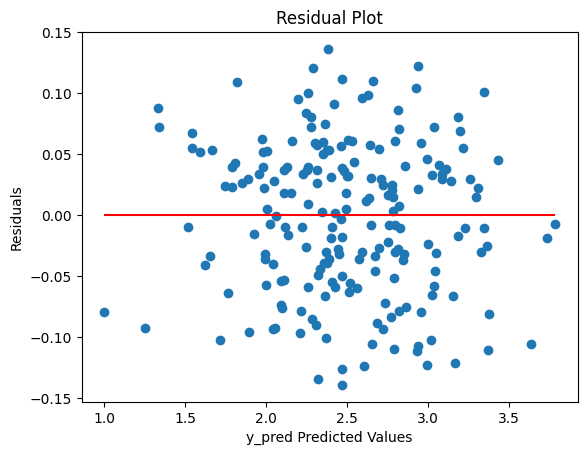

In [20]:
y_true = y_test
y_pred = model_1_pipeline.predict(X_test)

#compute residuals 
residuals = y_true - y_pred

#plot residuals
plt.scatter(y_pred, residuals)
plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color='red') #i made horizontal line through y = 0 to see the scatter pattern
plt.xlabel("y_pred Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

Random scatter of residuals

# Model #2: Decision Tree Classifier

In [ ]:
# Splitting target variable and features
X_2 = X
y_2 = df['quality_category']

In [ ]:
# Splitting the data into training, tuning, and test sets with stratification to maintain class distribution

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X_2, y_2, test_size=0.3, random_state=40, stratify=y_2
)

X2_tune, X2_test, y2_tune, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.5, random_state=40, stratify=y2_temp
)

In [69]:
# Encode the target variable for the decision tree model

le_target = LabelEncoder()
le_target.fit(y_2)

# Preprocess the categorical features using OrdinalEncoder for the decision tree model

preprocessor_2 = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), CAT)
    ],
    remainder="passthrough" # numerical columns will be passed through without transformation, as they are already normalized
)

# Create a pipeline that combines the preprocessor and the decision tree model
model_2_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('model', DecisionTreeClassifier(random_state=40)) # class_weight = 'balanced' did not improve the performance of the model, so default parameters for this model are used
])


# Perform 5-fold cross-validation on the training set to evaluate the model's performance
cv_scores = cross_val_score(
    model_2_pipeline,
    X2_train,
    y2_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross-validation scores:", cv_scores)
model_2_pipeline.fit(X2_train, y2_train)

Cross-validation scores: [0.85714286 0.8        0.79285714 0.88571429 0.87142857]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

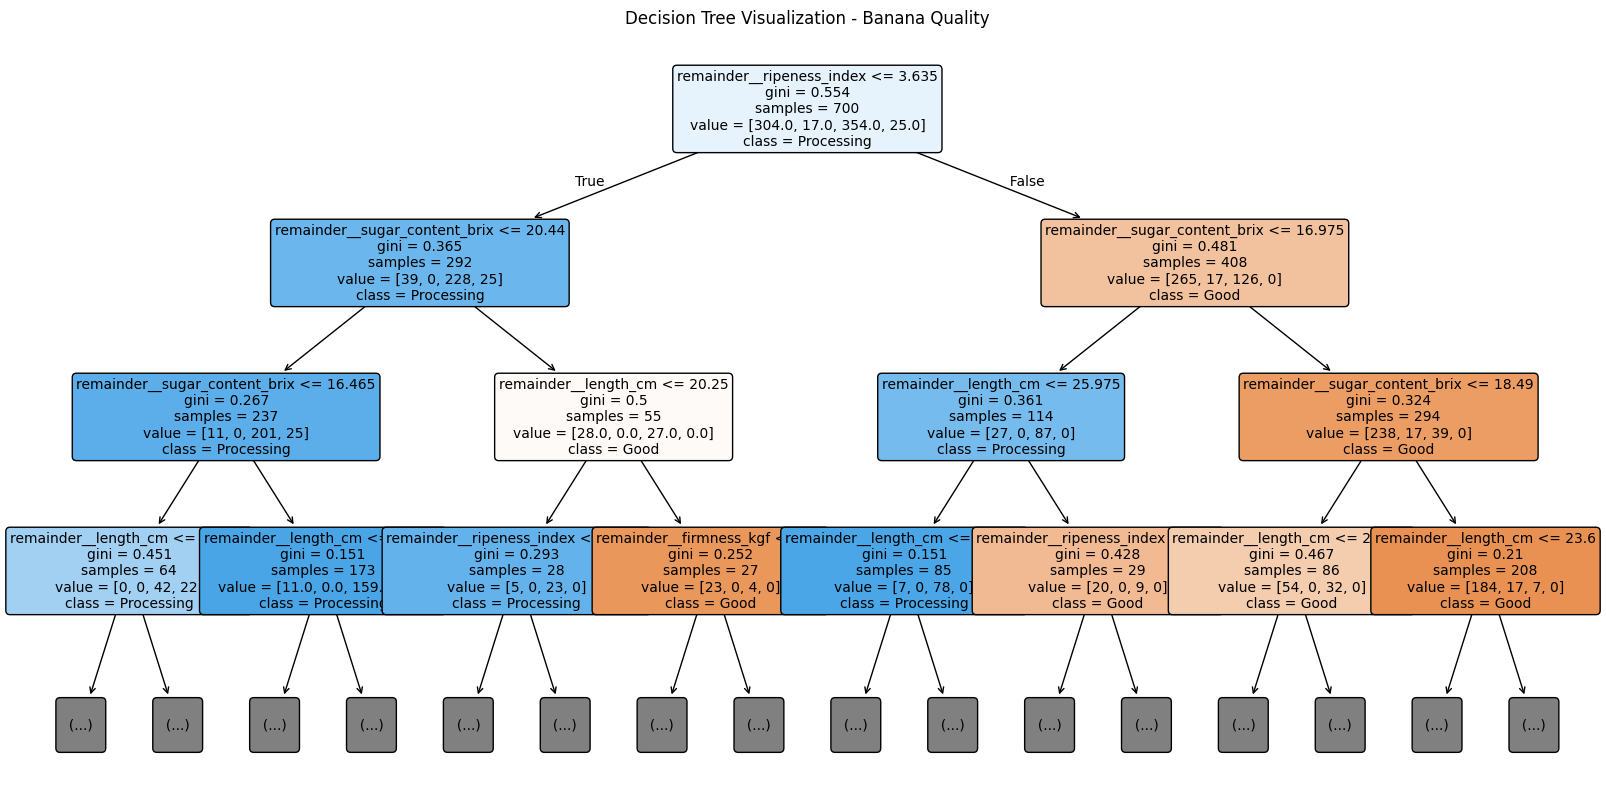

In [ ]:
# Visualize the decision tree

tree_model = model_2_pipeline.named_steps['model']


feature_names = model_2_pipeline.named_steps['preprocessor'].get_feature_names_out()


plt.figure(figsize=(20, 10)) 
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=le_target.classes_,
    filled=True,         # Colors nodes by class
    rounded=True,       # Makes boxes look nicer
    fontsize=10,
    max_depth=3          # Limits depth so the image isn't a mess of tiny text
)

plt.title("Decision Tree Visualization - Banana Quality")
plt.show()

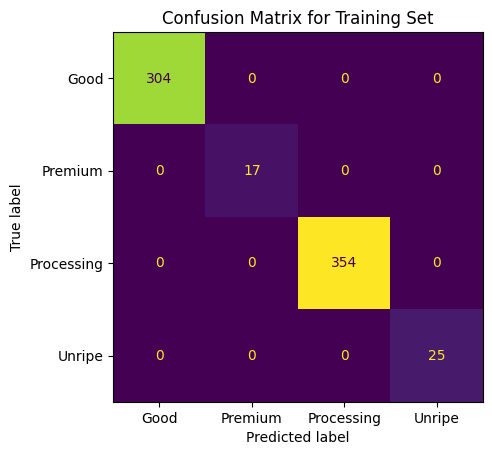

In [ ]:
# Evaluate model on training set using confusion matrix

y2_pred_train = model_2_pipeline.predict(X2_train)

disp = ConfusionMatrixDisplay.from_predictions(
    y2_train, y2_pred_train, 
    display_labels=le_target.classes_, 
    colorbar=False
    )
plt.title("Confusion Matrix for Training Set")
plt.show()

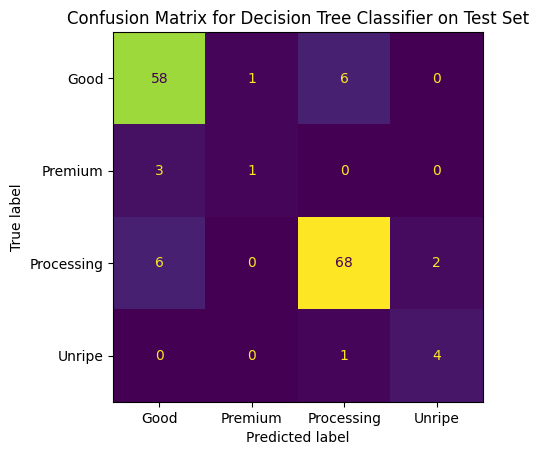

In [71]:
# Evaluate model on test set using confusion matrix

y2_pred_test = model_2_pipeline.predict(X2_test)
y2_prob_test = model_2_pipeline.predict_proba(X2_test)


disp = ConfusionMatrixDisplay.from_predictions(
    y2_test, y2_pred_test,
    display_labels=le_target.classes_,
    colorbar=False
)
plt.title('Confusion Matrix for Decision Tree Classifier on Test Set')
plt.show()

In [ ]:
# Calculate and print accuracy for the test set

accuracy = accuracy_score(results_test.target, results_test.pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8467


In [ ]:
# Print classification report for the test set

class_report = classification_report(y2_test, y2_pred_test, target_names=le_target.classes_)
print('Classification Report:')
print(class_report)


Classification Report:
              precision    recall  f1-score   support

        Good       0.87      0.89      0.88        65
     Premium       0.50      0.25      0.33         4
  Processing       0.91      0.89      0.90        76
      Unripe       0.67      0.80      0.73         5

    accuracy                           0.87       150
   macro avg       0.73      0.71      0.71       150
weighted avg       0.87      0.87      0.87       150



In [ ]:
# Calculate ROC AUC for the test set

y2_test_binary = label_binarize(y2_test, classes=le_target.classes_) # Need to convert the multiclass labels into a binary format for ROC AUC calculation
n_classes = y2_test_binary.shape[1]

macro_roc_auc = roc_auc_score(y2_test_binary, y2_prob_test, multi_class="ovr", average="macro") # Calculate the macro-averaged ROC AUC score across all classes
print(f'Macro-Averaged ROC AUC Score: {macro_roc_auc:.4f}')

Macro-Averaged ROC AUC Score: 0.8270


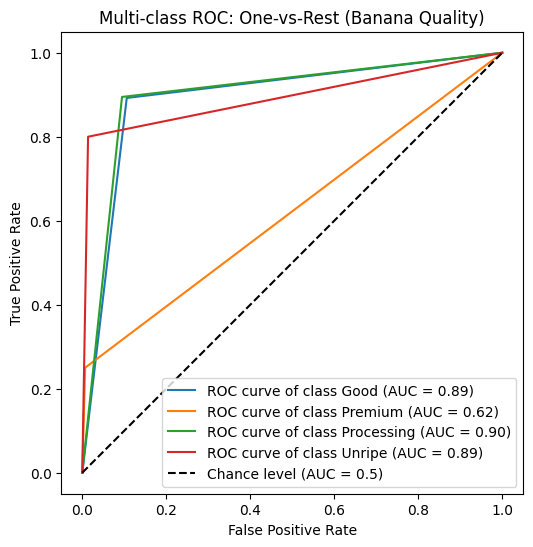

AUC Scores for each class:
Class Good: AUC = 0.89
Class Premium: AUC = 0.62
Class Processing: AUC = 0.90
Class Unripe: AUC = 0.89


In [ ]:
# Plot the ROC curves for each class

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_classes):
    RocCurveDisplay.from_predictions(
        y2_test_binary[:, i],
        y2_prob_test[:, i],
        name=f"ROC curve of class {le_target.classes_[i]}",
        ax=ax,
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC: One-vs-Rest (Banana Quality)")
plt.legend()
plt.show()

# AUC Scores for each class

print("AUC Scores for each class:")
for i in range(n_classes):
    auc_score = roc_auc_score(y2_test_binary[:, i], y2_prob_test[:, i])
    print(f"Class {le_target.classes_[i]}: AUC = {auc_score:.2f}")